In [8]:
#%pip install matplotlib

In [9]:
import csv
import numpy as np
import matplotlib.pyplot as plt

In [10]:
with open('data/8char-2bit-300-each-len.csv', 'r') as csvfile:
    reader = csv.DictReader(csvfile, delimiter=",")
    reader = list(reader)

    hit = [r['expected-LCS'] for r in reader if r['outcome'] == 'HIT']
    hit_counts = np.unique(hit, return_counts=True)

    misses = [r['expected-LCS'] for r in reader if r['outcome'] == 'MISS']
    miss_counts = np.unique(misses, return_counts=True)

print(hit_counts)
print(miss_counts)

(array(['1', '2', '3', '4', '5', '6', '7'], dtype='<U1'), array([300, 300, 300, 299, 300, 297, 296]))
(array(['4', '6', '7'], dtype='<U1'), array([1, 3, 4]))


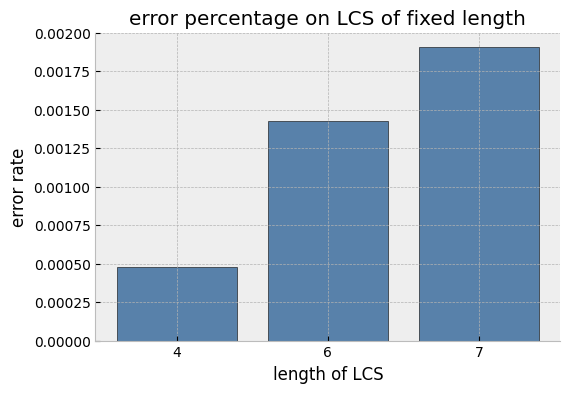

In [ ]:
tot = np.sum(miss_counts[1]) + np.sum(hit_counts[1])


fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(miss_counts[0], miss_counts[1]/tot, color='#336699', edgecolor='black', alpha=0.8)


plt.style.use('bmh')
plt.xlabel("length of LCS")
plt.ylabel("error rate")
plt.title("error percentage on LCS of fixed length")


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("0", dpi=200)
plt.show()

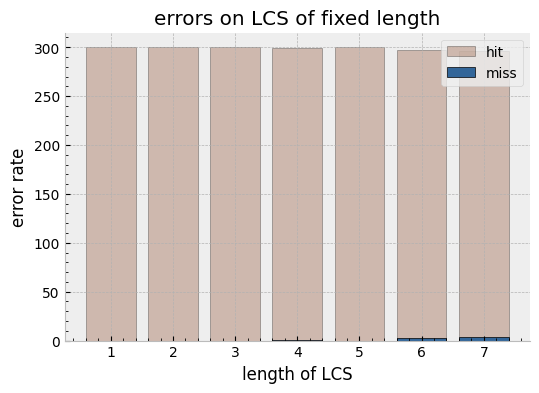

In [12]:
tot = np.sum(miss_counts[1])
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(hit_counts[0], hit_counts[1], color="#9F694E", edgecolor='black', alpha=0.4)
ax.bar(miss_counts[0], miss_counts[1], color='#336699', edgecolor='black', alpha=1)


plt.style.use('bmh')
plt.xlabel("length of LCS")
plt.ylabel("error rate")
plt.title("errors on LCS of fixed length")
plt.legend(["hit", "miss"])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.minorticks_on()
plt.savefig("1", dpi= 200)
plt.show()

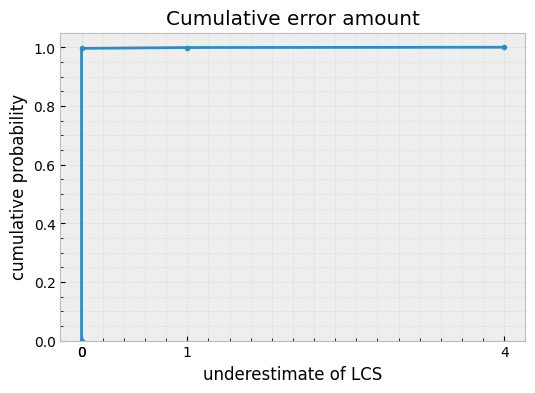

In [14]:
with open('data/8char-2bit-300-each-len.csv', 'r') as csvfile:
    reader = csv.DictReader(csvfile, delimiter=",")
    reader = list(reader)

    misses = [(r['expected-LCS'], r['found-LCS']) for r in reader]


errors = [int(x) - int(y) for x, y in misses]
values, counts = np.unique(errors, return_counts=True)

counts_cum = np.cumsum(counts)

v_plot = np.insert(values, 0, 0)
c_plot = np.insert(counts_cum, 0, 0)

c_plot_norm = c_plot / c_plot[-1]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(v_plot, c_plot_norm, marker='.', linestyle='-')
ax.minorticks_on()
ax.grid(which='both', linestyle=':', alpha=0.5)
ax.set_xticks(v_plot)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.6)

ax.set_ylabel("cumulative probability")
ax.set_xlabel("underestimate of LCS")

ax.set_title("Cumulative error amount")

plt.savefig("2", dpi= 200)
plt.show()